In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt



### Double Integrator Dynamics 

The robot has a simple point mass dynamics, where the state of the robot is given by its position and velocity. The control input is the acceleration of the robot. The dynamics can be written as:
$$\begin{align*}
x_{t+1} &= x_t + v_t \Delta t + \frac{1}{2} a_t \Delta t^2 \\
v_{t+1} &= v_t + a_t \Delta t   
\end{align*}$$

Where $x_t$ is the position of the robot at time $t$, $v_t$ is the velocity of the robot at time $t$, $a_t$ is the acceleration of the robot at time $t$, and $\Delta t$ is the time step.  

We can write these dynamics in a more compact form as:
$$\begin{align*}
\begin{bmatrix}x_{t+1} \\
v_{t+1}\end{bmatrix} = \begin{bmatrix}1 & \Delta t \\
0 & 1\end{bmatrix} \begin{bmatrix}x_t \
v_t\end{bmatrix} + \begin{bmatrix}\frac{1}{2} \Delta t^2 \\ \Delta t\end{bmatrix} a_t
\end{align*}$$  


In state space form, we can write the dynamics as:
$$\begin{align*}
s_{t+1} = A s_t + B a_t
\end{align*}$$

Where $s_t = \begin{bmatrix}x_t \\ v_t\end{bmatrix}$ is the state of the robot at time $t$, $A = \begin{bmatrix}1 & \Delta t \\ 0 & 1\end{bmatrix}$ is the state transition matrix, and $B = \begin{bmatrix}\frac{1}{2} \Delta t^2 \\ \Delta t\end{bmatrix}$ is the control input matrix.


For a 2d problem, we can expand the state and control vectors to 
$$\begin{align*}
s_t = \begin{bmatrix}x_t \\ y_t \\ v_{x,t} \\ v_{y,t}\end{bmatrix}, \quad a_t = \begin{bmatrix}a_{x,t} \\ a_{y,t}\end{bmatrix}
\end{align*}$$
And the dynamics can be written as:
$$\begin{align*}
A = \begin{bmatrix}1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1\end{bmatrix}, \quad B = \begin{bmatrix}\frac{1}{2} \Delta t^2 & 0 \\ 0 & \frac{1}{2} \Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t\end{bmatrix}
\end{align*}$$




Optimal value:  24.00240024002386
Fuel used:  4.243064993618635


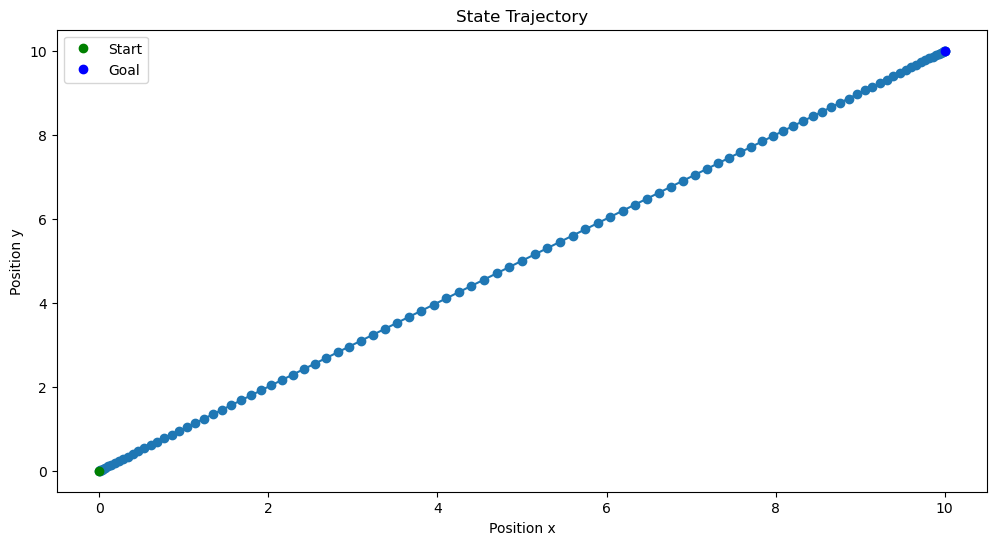

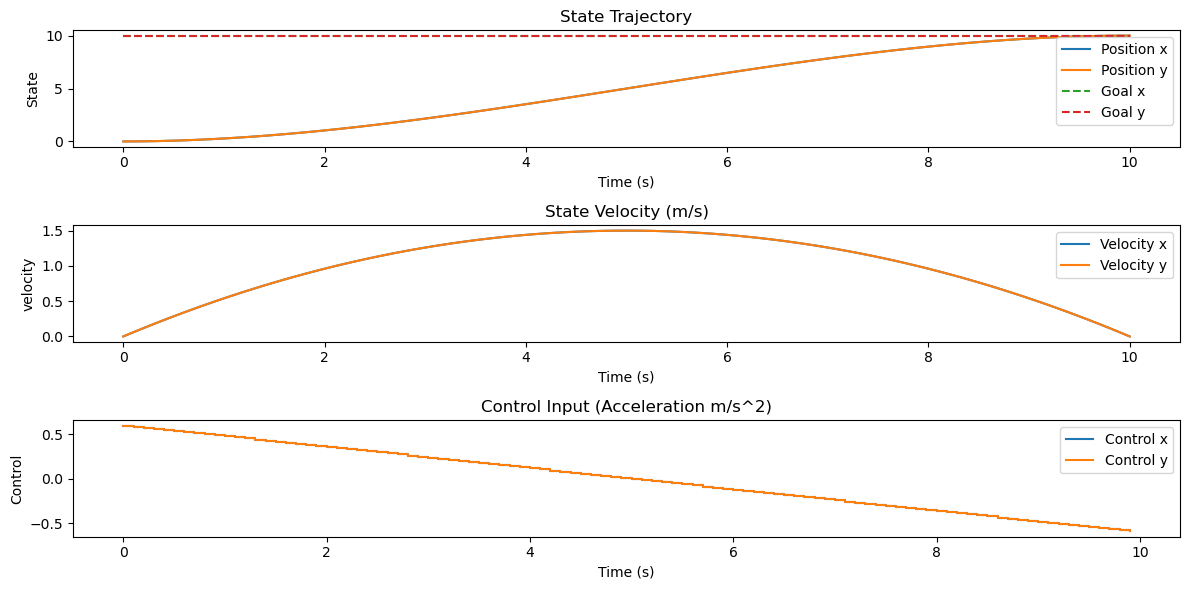

In [3]:
# simple double integrator example

T_time_horizon = 10 #seconds
dt = 0.1
N = int(T_time_horizon / dt) # total number of time steps

# Optimization variables
s = cp.Variable((4, N + 1)) # s = [x,y, vx, vy]
a = cp.Variable((2, N)) # a = [ax, ay]


# initial and final conditions
s_init = np.array([0, 0, 0, 0])
s_final = np.array([10, 10, 0, 0])




A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
                [0, 0, 1, 0],
                [0, 0, 0, 1]])
B = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])


# Initial and Terminal State Constraints
constraints = [s[:, 0] == s_init]
constraints += [s[:, N] == s_final]


# Dynamics constraints
for t in range(N):
    constraints += [s[:, t + 1] == A @ s[:, t] + B @ a[:, t]]




objective = cp.Minimize(cp.sum_squares(a)) # Note this isn't actually control effort optimal for that you would want to use a different norm 

problem = cp.Problem(objective, constraints)
problem.solve()

fuel_used = np.sum(np.linalg.norm(a.value, axis=0)) * dt

print("Optimal value: ", problem.value)
print("Fuel used: ", fuel_used)

# plot results
#plot x and y plots of the state
plt.figure(figsize=(12, 6))
plt.plot(s.value[0, :], s.value[1, :], marker='o')
plt.plot(s_init[0], s_init[1], 'go', label='Start')
plt.plot(s_final[0], s_final[1], 'bo', label='Goal')
plt.title('State Trajectory')
plt.xlabel('Position x')
plt.ylabel('Position y')
plt.legend()

ones = np.ones((2, N + 1))

time = np.arange(N + 1) * dt
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, s.value[0, :], label='Position x')
plt.plot(time, s.value[1, :], label='Position y')

plt.plot(time, s_final[0] * ones[0, :], linestyle='--', label='Goal x')
plt.plot(time, s_final[1] * ones[1, :], linestyle='--', label='Goal y')
plt.title('State Trajectory')
plt.xlabel('Time (s)')
plt.ylabel('State')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(time, s.value[2, :], label='Velocity x')
plt.plot(time, s.value[3, :], label='Velocity y')
plt.title('State Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('velocity')
plt.legend()
plt.subplot(3, 1, 3)
plt.step(time[:-1], a.value[0, :], where='post', label='Control x')
plt.step(time[:-1], a.value[1, :], where='post', label='Control y')
plt.title('Control Input (Acceleration m/s^2)')
plt.xlabel('Time (s)')
plt.ylabel('Control')
plt.legend()
plt.tight_layout()
plt.show()





solver status:  optimal
Optimal value:  157.73091024345766


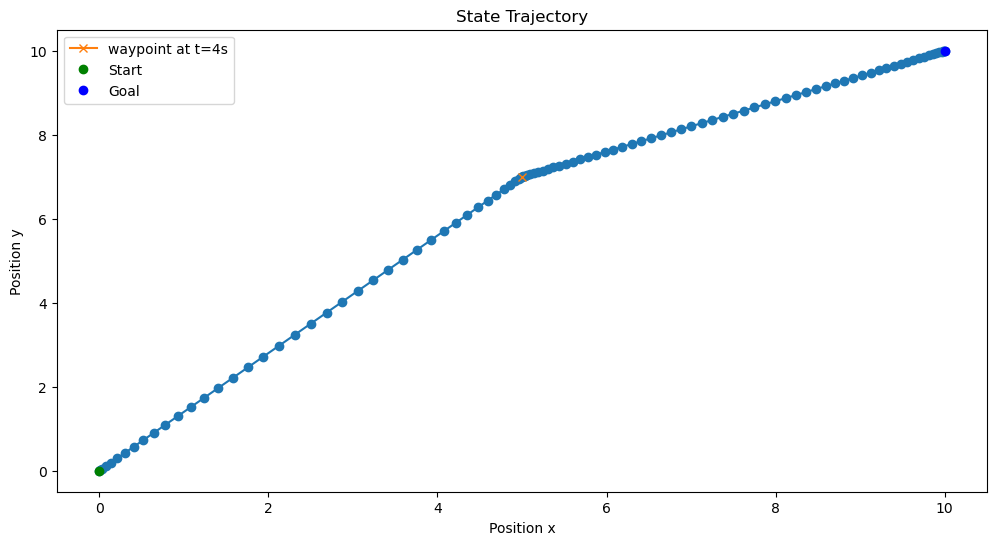

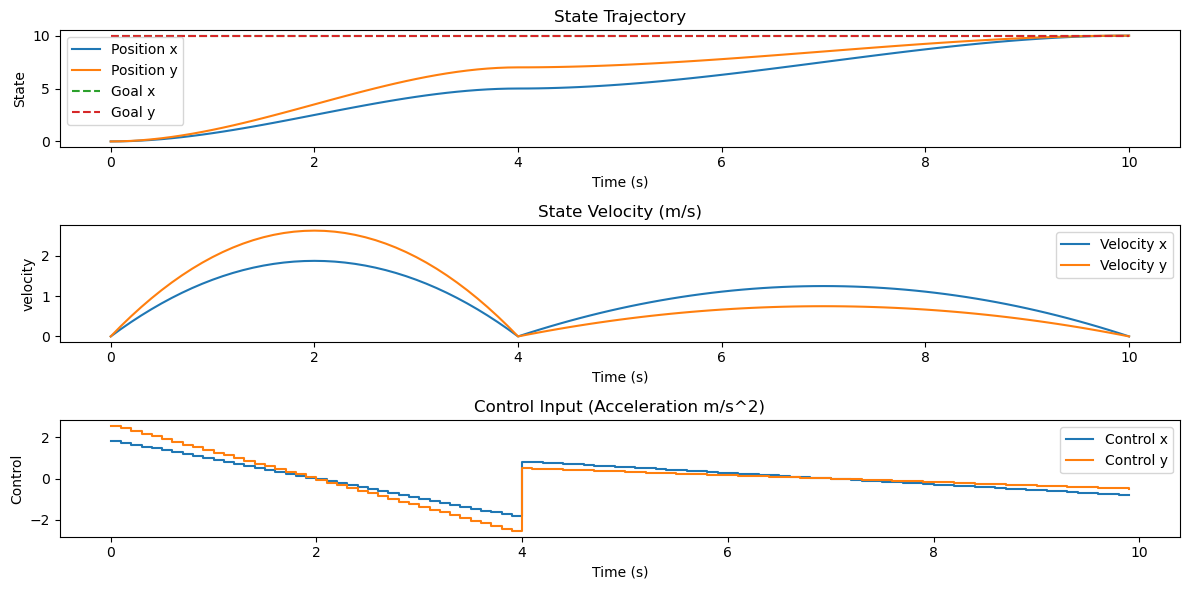

In [7]:
# simple double integrator example with waypoint

T_time_horizon = 10 #seconds
dt = 0.1
N = int(T_time_horizon / dt)

# Optimization variables
s = cp.Variable((4, N + 1)) # s = [x,y, vx, vy]
a = cp.Variable((2, N)) # a = [ax, ay]


# initial and final conditions
s_init = np.array([0, 0, 0, 0])
s_final = np.array([10, 10, 0, 0])




A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
                [0, 0, 1, 0],
                [0, 0, 0, 1]])
B = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])


# Initial and Terminal State Constraints
constraints = [s[:, 0] == s_init]
constraints += [s[:, N] == s_final]


# Dynamics constraints
for t in range(N):
    constraints += [s[:, t + 1] == A @ s[:, t] + B @ a[:, t]]



# At t= 4 s we need to be at s = [5, 7]
constraints += [s[:, 40] == np.array([5, 7, 0,0])]


# control constraint
#constraints += [cp.norm(a[:, t]) <= 3 for t in range(N)]




objective = cp.Minimize(cp.sum_squares(a))
problem = cp.Problem(objective, constraints)
problem.solve()

print("solver status: ", problem.status)

print("Optimal value: ", problem.value)



ones = np.ones((2, N + 1))
# plot results
#plot x and y plots of the state
plt.figure(figsize=(12, 6))
plt.plot(s.value[0, :], s.value[1, :], marker='o')
plt.plot(s.value[0, 40], s.value[1, 40], marker='x', label='waypoint at t=4s')
plt.plot(s_init[0], s_init[1], 'go', label='Start')
plt.plot(s_final[0], s_final[1], 'bo', label='Goal')
plt.title('State Trajectory')
plt.xlabel('Position x')
plt.ylabel('Position y')
plt.legend()



time = np.arange(N + 1) * dt
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, s.value[0, :], label='Position x')
plt.plot(time, s.value[1, :], label='Position y')

plt.plot(time, s_final[0] * ones[0, :], linestyle='--', label='Goal x')
plt.plot(time, s_final[1] * ones[1, :], linestyle='--', label='Goal y')
plt.title('State Trajectory')
plt.xlabel('Time (s)')
plt.ylabel('State')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(time, s.value[2, :], label='Velocity x')
plt.plot(time, s.value[3, :], label='Velocity y')
plt.title('State Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('velocity')
plt.legend()
plt.subplot(3, 1, 3)
plt.step(time[:-1], a.value[0, :], where='post', label='Control x')
plt.step(time[:-1], a.value[1, :], where='post', label='Control y')
plt.title('Control Input (Acceleration m/s^2)')
plt.xlabel('Time (s)')
plt.ylabel('Control')
plt.legend()
plt.tight_layout()
plt.show()


Optimal value:  44.04652423537336


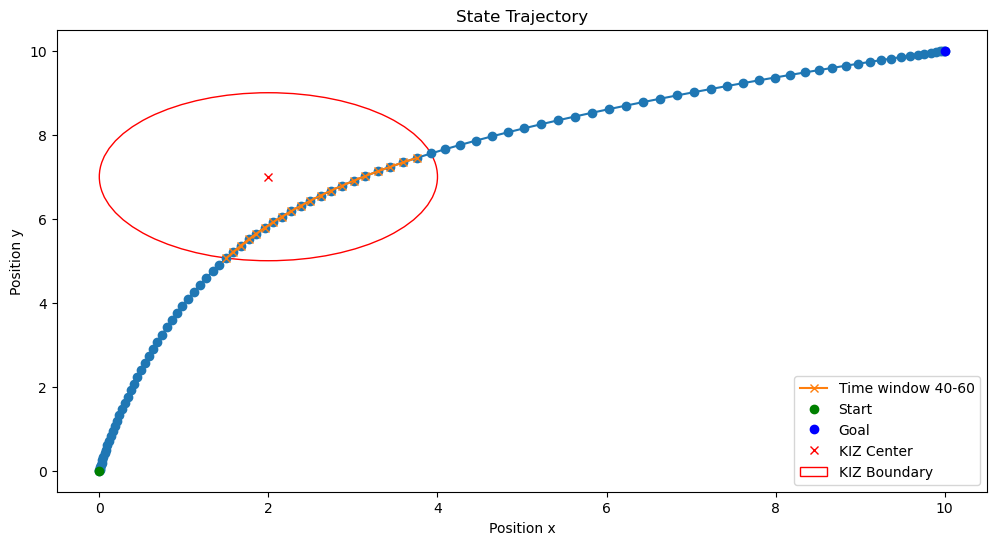

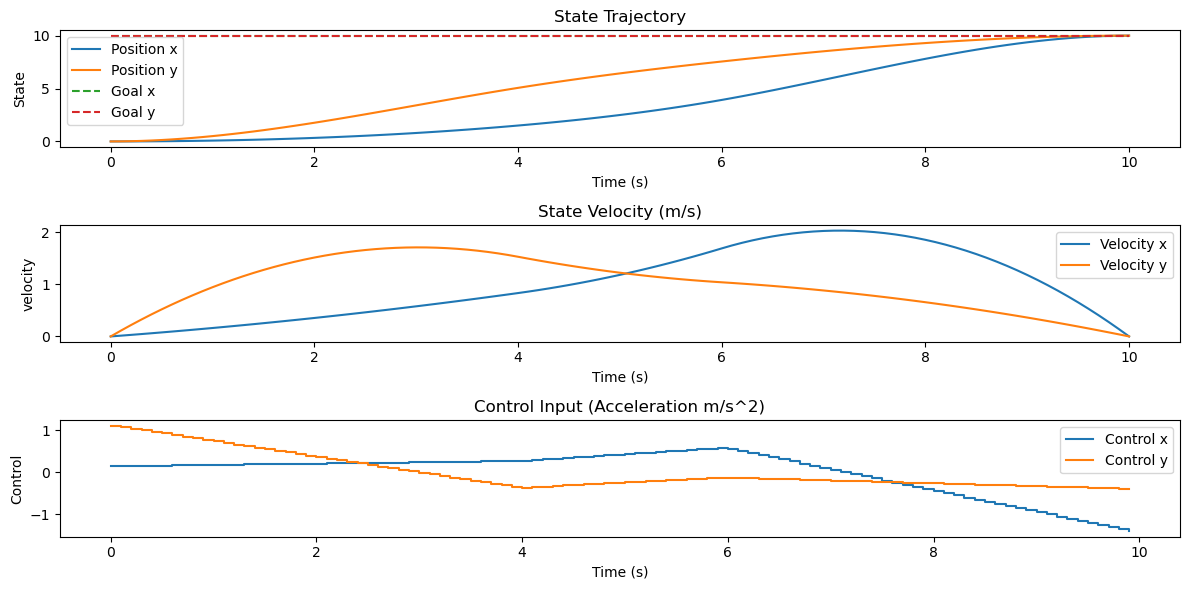

In [8]:
# simple double integrator example with waypoint

T_time_horizon = 10 #seconds
dt = 0.1
N = int(T_time_horizon / dt)

# Optimization variables
s = cp.Variable((4, N + 1)) # s = [x,y, vx, vy]
a = cp.Variable((2, N)) # a = [ax, ay]




# initial and final conditions
s_init = np.array([0, 0, 0, 0])
s_final = np.array([10, 10, 0, 0])




A = np.array([[1, 0, dt, 0],
              [0, 1, 0, dt],
                [0, 0, 1, 0],
                [0, 0, 0, 1]])
B = np.array([[0.5 * dt**2, 0],
              [0, 0.5 * dt**2],
              [dt, 0],
              [0, dt]])


# Initial and Terminal State Constraints
constraints = [s[:, 0] == s_init]
constraints += [s[:, N] == s_final]


# Dynamics constraints
for t in range(N):
    constraints += [s[:, t + 1] == A @ s[:, t] + B @ a[:, t]]




KIZ_center = np.array([2, 7])
KIZ_radius = 2

# between t =4s and t =6s I need to be with 2m of the point (5, 7)
for t in range(40, 61):
    constraints += [cp.norm(s[:2, t] - KIZ_center, 2) <= KIZ_radius]


    # go slow when in KIZ
    #constraints += [s[2:, t] == 1]
    #constraints += [cp.norm(a[:, t]) <= 0] 



# control and velocity constraints
#constraints += [cp.norm(a[:, t], 'inf') <= 2 for t in range(N)]
#constraints += [cp.norm(s[2:, t], 'inf') <= 3 for t in range(N + 1)]


ones = np.ones((2, N + 1))

# create a matrix of the final state repeated N+1 times for the cost function
s_final_matrix = np.tile(s_final[:2].reshape(-1, 1), (1, N + 1))




#objective = cp.Minimize(cp.sum_squares(a) +   cp.sum_squares(s[:2] - s_final_matrix))
objective = cp.Minimize(cp.sum_squares(a))
problem = cp.Problem(objective, constraints)
problem.solve()

print("Optimal value: ", problem.value)



# plot results
#plot x and y plots of the state
plt.figure(figsize=(12, 6))
plt.plot(s.value[0, :], s.value[1, :], marker='o')
plt.plot(s.value[0, 40:60], s.value[1, 40:60], marker='x', label='Time window 40-60')
plt.plot(s_init[0], s_init[1], 'go', label='Start')
plt.plot(s_final[0], s_final[1], 'bo', label='Goal')
plt.plot(KIZ_center[0], KIZ_center[1], 'rx', label='KIZ Center')
circle = plt.Circle(KIZ_center, KIZ_radius, color='r', fill=False, label='KIZ Boundary')
plt.gca().add_artist(circle)
plt.title('State Trajectory')
plt.xlabel('Position x')
plt.ylabel('Position y')
plt.legend()



time = np.arange(N + 1) * dt
plt.figure(figsize=(12, 6))
plt.subplot(3, 1, 1)
plt.plot(time, s.value[0, :], label='Position x')
plt.plot(time, s.value[1, :], label='Position y')

plt.plot(time, s_final[0] * ones[0, :], linestyle='--', label='Goal x')
plt.plot(time, s_final[1] * ones[1, :], linestyle='--', label='Goal y')
plt.title('State Trajectory')
plt.xlabel('Time (s)')
plt.ylabel('State')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(time, s.value[2, :], label='Velocity x')
plt.plot(time, s.value[3, :], label='Velocity y')
plt.title('State Velocity (m/s)')
plt.xlabel('Time (s)')
plt.ylabel('velocity')
plt.legend()
plt.subplot(3, 1, 3)
plt.step(time[:-1], a.value[0, :], where='post', label='Control x')
plt.step(time[:-1], a.value[1, :], where='post', label='Control y')
plt.title('Control Input (Acceleration m/s^2)')
plt.xlabel('Time (s)')
plt.ylabel('Control')
plt.legend()
plt.tight_layout()
plt.show()
